In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled")

PyTorch: 2.11.0+cpu
CUDA available: False


In [3]:
!pip install -q -U transformers accelerate sentencepiece

In [4]:
import transformers
import accelerate

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)

Transformers: 5.17.0
Accelerate: 1.14.0


In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
# IMAGE_PATH = "/content/drive/MyDrive/Meenakshi /Dataset/handwriteen/handwrittennotesTest.jpg"
# This variable is no longer needed as we'll process all images from the directory.

In [7]:
import os

DIRECTORY_PATH = "/content/drive/MyDrive/Meenakshi/Dataset/handwriteen/"

image_files = []
for root, _, files in os.walk(DIRECTORY_PATH):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

print(f"Found {len(image_files)} image files in {DIRECTORY_PATH}")
if len(image_files) > 5:
    print("First 5 image files:", image_files[:5])
else:
    print("Image files:", image_files)

Found 10 image files in /content/drive/MyDrive/Meenakshi/Dataset/handwriteen/
First 5 image files: ['/content/drive/MyDrive/Meenakshi/Dataset/handwriteen/Screenshot_1.png', '/content/drive/MyDrive/Meenakshi/Dataset/handwriteen/hand2.png', '/content/drive/MyDrive/Meenakshi/Dataset/handwriteen/scraphand1.png', '/content/drive/MyDrive/Meenakshi/Dataset/handwriteen/scraphand3.png', '/content/drive/MyDrive/Meenakshi/Dataset/handwriteen/scraphand4.png']


In [8]:
import os
import json
import csv
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

Image size: (526, 311)


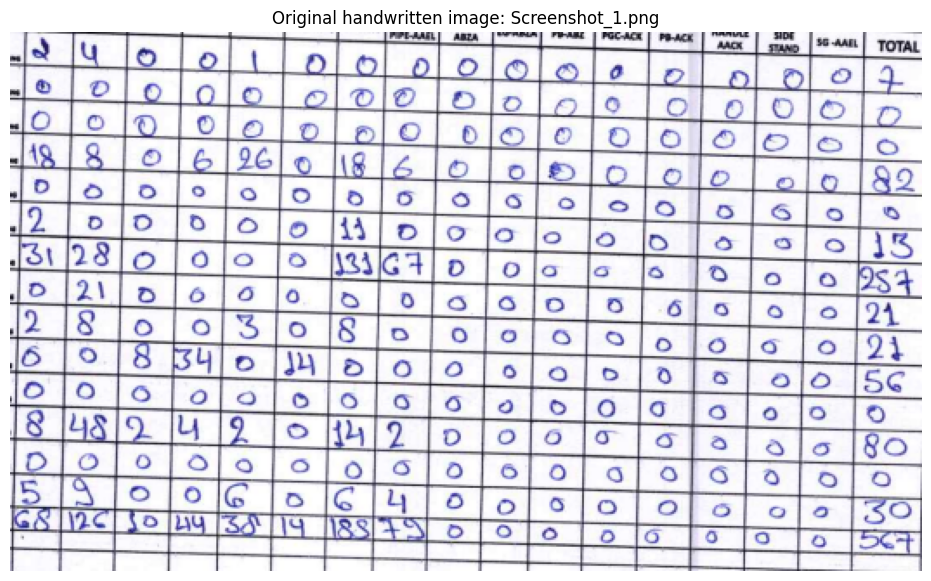

In [9]:
# For demonstration, let's process the first image found in the directory
if image_files:
    current_image_path = image_files[0]
    image = Image.open(current_image_path).convert("RGB")

    print("Image size:", image.size)

    plt.figure(figsize=(14, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Original handwritten image: {os.path.basename(current_image_path)}")
    plt.show()
else:
    print("No image files found in the specified directory.")

## Preprocessing

Upscale + contrast-boost + denoise. This output is what actually gets fed to the OCR model
below (in the previous version it was computed but never used) — small handwritten cells
need the resolution/contrast boost to give the model a chance.

Ruled table lines are removed separately, after cell boxes are detected (see
`remove_grid_lines` below) — GOT otherwise reads the ruled border as part of the
character (a digit next to a horizontal rule can get read as if it had a line through it).


In [11]:
def preprocess_handwriting(image, scale=3):
    """
    Enhance a handwriting image for OCR: grayscale, upscale, local contrast boost,
    light denoise. Returns a grayscale numpy array.

    `scale` is returned implicitly via the caller-tracked PREPROCESS_SCALE constant
    below, so box coordinates found on the ORIGINAL-resolution image can be mapped
    onto this upscaled array later.
    """
    img = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    upscaled = cv2.resize(
        gray,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_CUBIC
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    enhanced = clahe.apply(upscaled)

    denoised = cv2.fastNlMeansDenoising(
        enhanced,
        None,
        h=5,
        templateWindowSize=7,
        searchWindowSize=21
    )

    return denoised

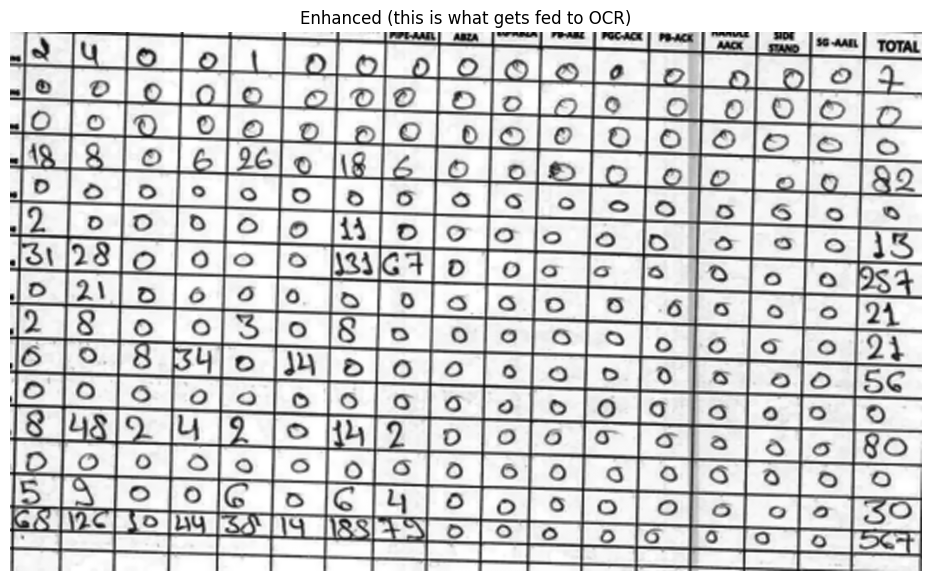

In [16]:
PREPROCESS_SCALE = 5
enhanced = preprocess_handwriting(image, scale=PREPROCESS_SCALE)

plt.figure(figsize=(14, 7))
plt.imshow(enhanced, cmap="gray")
plt.axis("off")
plt.title("Enhanced (this is what gets fed to OCR)")
plt.show()

## Detect OCR regions — grid or no grid

No hardcoded boxes. `detect_cells()` checks whether the image actually has ruled table
lines (by measuring how much of the image is covered by long straight strokes):

- **Grid found** -> read off the row/column line positions from the line mask and build
  cells from consecutive line pairs.
- **No grid** -> fall back to finding ink blobs (contours), clustering them into text
  rows by vertical position, then splitting each row into cells by horizontal gaps.

Either path returns the same kind of `{name: (x1, y1, x2, y2)}` dict, so everything
downstream (cropping, OCR) doesn't need to know which case it was.

In [17]:
def get_line_masks(image):
    """
    Binarize the image and isolate long horizontal / vertical strokes
    (i.e. ruled table lines, as opposed to handwriting).
    """
    gray = cv2.cvtColor(np.array(image.convert("RGB")), cv2.COLOR_RGB2GRAY)

    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        21,
        10
    )

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (max(20, image.width // 10), 1)
    )
    horizontal = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, max(20, image.height // 10))
    )
    vertical = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)

    return horizontal, vertical, binary


def has_grid(image, coverage_threshold=0.008):
    """
    Decide whether the image contains ruled table lines: what fraction of the
    image area is covered by long horizontal/vertical strokes.
    """
    horizontal, vertical, _ = get_line_masks(image)
    line_pixels = np.count_nonzero(horizontal) + np.count_nonzero(vertical)
    coverage = line_pixels / (image.width * image.height)
    return coverage > coverage_threshold, coverage

In [18]:
def find_line_positions(mask, axis, min_gap=10, strength_ratio=0.3):
    """
    Collapse a line mask to 1D by projecting along `axis`, then return the
    coordinate of each strong peak (a detected grid line), merging peaks
    that fall within `min_gap` of each other.

    axis=1 -> project rows -> horizontal line y-positions
    axis=0 -> project columns -> vertical line x-positions
    """
    profile = mask.sum(axis=axis) / 255
    threshold = profile.max() * strength_ratio if profile.max() > 0 else 0

    positions = np.where(profile > threshold)[0]
    if len(positions) == 0:
        return []

    lines = [positions[0]]
    for p in positions[1:]:
        if p - lines[-1] > min_gap:
            lines.append(p)
        else:
            lines[-1] = int((lines[-1] + p) / 2)

    return sorted(set(int(l) for l in lines))

In [19]:
def boxes_from_grid(image, min_cell_size=15, min_ink_ratio=0.005, inset=3):
    """
    Build cell boxes from detected ruled-line positions. Image edges act as
    implicit outer lines so edge cells are still captured.

    Cells with (almost) no ink once the ruled lines are removed are skipped.
    This drops the empty margins between the image edge and the table's outer
    border, as well as blank cells, so they aren't sent to OCR.
    """
    horizontal, vertical, binary = get_line_masks(image)

    # handwriting only: binary ink with the ruled lines subtracted
    ink = cv2.bitwise_and(binary, cv2.bitwise_not(cv2.bitwise_or(horizontal, vertical)))

    row_lines = find_line_positions(horizontal, axis=1)
    col_lines = find_line_positions(vertical, axis=0)

    row_lines = sorted(set([0] + row_lines + [image.height]))
    col_lines = sorted(set([0] + col_lines + [image.width]))

    boxes = {}
    for r in range(len(row_lines) - 1):
        y1, y2 = row_lines[r], row_lines[r + 1]
        if y2 - y1 < min_cell_size:
            continue
        for c in range(len(col_lines) - 1):
            x1, x2 = col_lines[c], col_lines[c + 1]
            if x2 - x1 < min_cell_size:
                continue

            # measure ink slightly inside the cell so leftover line edges don't count
            region = ink[y1 + inset:y2 - inset, x1 + inset:x2 - inset]
            if region.size == 0 or np.count_nonzero(region) / region.size < min_ink_ratio:
                continue

            boxes[f"r{r}_c{c}"] = (x1, y1, x2, y2)

    return boxes

In [20]:
def boxes_from_text_regions(image, row_gap_ratio=0.02, min_area=40):
    """
    Fallback for images with NO ruled lines: find ink blobs, cluster them
    into text rows by vertical position, then order each row left to right.
    Each blob becomes its own cell box (this does not try to guess column
    boundaries the way a ruled grid does).
    """
    gray = cv2.cvtColor(np.array(image.convert("RGB")), cv2.COLOR_RGB2GRAY)
    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        21,
        10
    )

    # close up strokes within a word/digit so contours merge into whole tokens
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 5))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    rects = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > min_area]

    if not rects:
        return {}

    rects.sort(key=lambda r: r[1])
    row_gap = image.height * row_gap_ratio
    rows = [[rects[0]]]

    for rect in rects[1:]:
        prev_bottom = max(r[1] + r[3] for r in rows[-1])
        if rect[1] - prev_bottom > row_gap:
            rows.append([rect])
        else:
            rows[-1].append(rect)

    boxes = {}
    for r_idx, row in enumerate(rows):
        row.sort(key=lambda r: r[0])
        for c_idx, (x, y, w, h) in enumerate(row):
            boxes[f"r{r_idx}_c{c_idx}"] = (x, y, x + w, y + h)

    return boxes

In [21]:
def detect_cells(image):
    """
    Automatically detect OCR-able regions, whether or not the image has
    ruled table lines. Returns (boxes, mode).
    """
    grid_found, coverage = has_grid(image)
    print(f"Grid line coverage: {coverage:.4f} -> {'grid detected' if grid_found else 'no grid'}")

    if grid_found:
        boxes = boxes_from_grid(image)
        mode = "grid"
    else:
        boxes = boxes_from_text_regions(image)
        mode = "text_regions"

    return boxes, mode

Grid line coverage: 0.1391 -> grid detected
Mode: grid, cells detected: 17


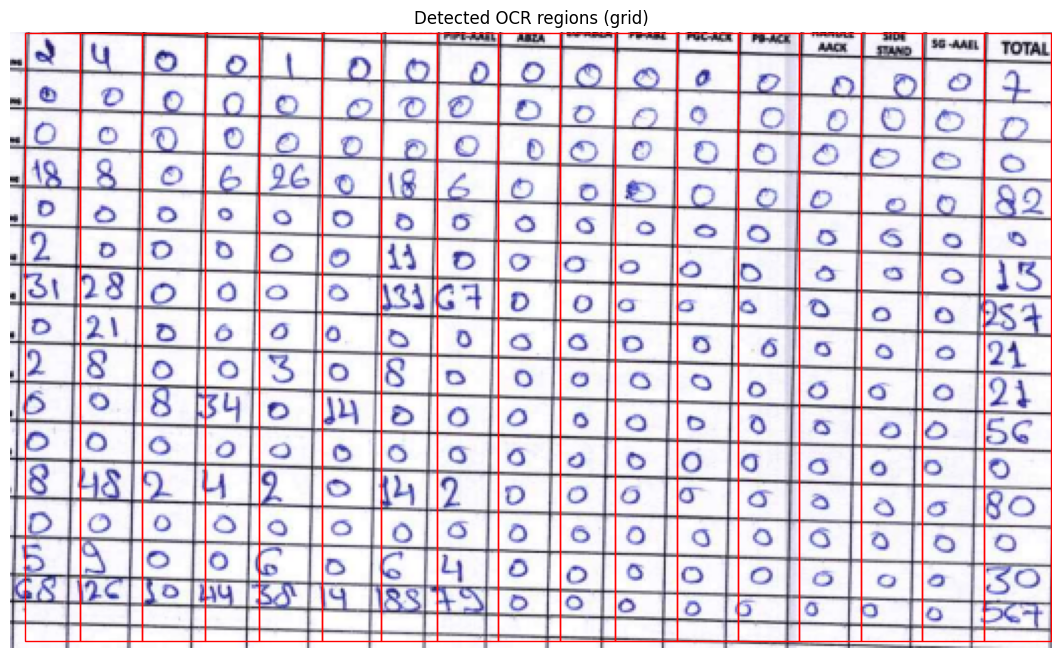

In [22]:
boxes, mode = detect_cells(image)
print(f"Mode: {mode}, cells detected: {len(boxes)}")

img_np = np.array(image)
plt.figure(figsize=(14, 8))
plt.imshow(img_np)

for name, (x1, y1, x2, y2) in boxes.items():
    rectangle = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=1,
        edgecolor="red"
    )
    plt.gca().add_patch(rectangle)

plt.axis("off")
plt.title(f"Detected OCR regions ({mode})")
plt.show()

## Remove grid lines before OCR

GOT (and TrOCR) otherwise see the ruled border as part of the glyph — a digit sitting on a horizontal rule can get read as if the rule were a stroke through it. `remove_grid_lines` reuses the horizontal/vertical line masks from grid detection, dilates them slightly, upscales them to match `enhanced`, and inpaints those pixels so cropped cells go into OCR clean.


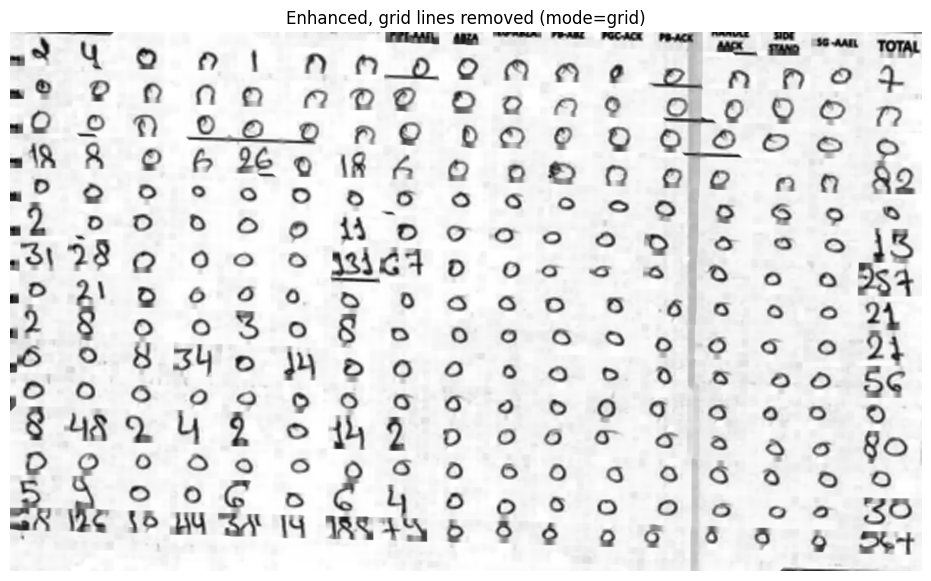

In [ ]:
def remove_grid_lines(enhanced, image, scale, dilate_px=2):
    """
    Erase ruled table lines from the enhanced/upscaled grayscale array before it's
    cropped and sent to OCR. Grid lines are detected on the ORIGINAL-resolution
    image (reusing get_line_masks), then the mask is dilated and upscaled by
    `scale` to line up with `enhanced`, and the marked pixels are inpainted so the
    handwriting isn't left with a hard white gap where a rule used to be.
    """
    horizontal, vertical, _ = get_line_masks(image)
    line_mask = cv2.bitwise_or(horizontal, vertical)

    if not np.any(line_mask):
        return enhanced

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (dilate_px * 2 + 1, dilate_px * 2 + 1))
    line_mask = cv2.dilate(line_mask, kernel)

    line_mask = cv2.resize(
        line_mask,
        (enhanced.shape[1], enhanced.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    return cv2.inpaint(enhanced, line_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)


enhanced = remove_grid_lines(enhanced, image, scale=PREPROCESS_SCALE) if mode == "grid" else enhanced

plt.figure(figsize=(14, 7))
plt.imshow(enhanced, cmap="gray")
plt.axis("off")
plt.title(f"Enhanced, grid lines removed (mode={mode})")
plt.show()


## Crop cells from the enhanced image

Boxes were found on the original-resolution image, so coordinates are scaled up by
`PREPROCESS_SCALE` to map onto the enhanced array. Cells are cropped in grayscale
(no hard binarization) — binarizing before OCR was likely a big part of why the
previous version produced gibberish.

Before cropping, ruled grid lines (if any were detected) are erased from the enhanced
image with `remove_grid_lines`, so the horizontal/vertical rules don't bleed into the
crop and get read as part of a character.


In [24]:
def crop_box_from_enhanced(enhanced, box, scale, padding=3):
    """
    Crop a cell out of the enhanced/upscaled grayscale array, mapping a box
    found on the original-resolution image up by `scale`.
    """
    x1, y1, x2, y2 = box
    X1 = max(0, int(x1 * scale) - padding * scale)
    Y1 = max(0, int(y1 * scale) - padding * scale)
    X2 = min(enhanced.shape[1], int(x2 * scale) + padding * scale)
    Y2 = min(enhanced.shape[0], int(y2 * scale) + padding * scale)

    return Image.fromarray(enhanced[Y1:Y2, X1:X2])


cell_images = {
    name: crop_box_from_enhanced(enhanced, box, scale=PREPROCESS_SCALE)
    for name, box in boxes.items()
}

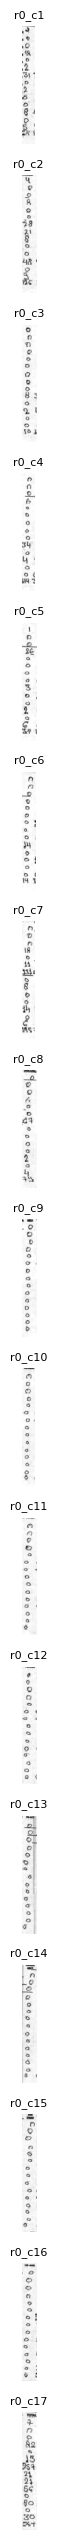

In [25]:
n = len(cell_images)
fig, axes = plt.subplots(n, 1, figsize=(10, max(n, 1) * 1.5))

if n == 1:
    axes = [axes]

for ax, (name, crop) in zip(axes, cell_images.items()):
    ax.imshow(crop, cmap="gray")
    ax.set_title(name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Load GOT-OCR-2.0

In [26]:
MODEL_ID = "stepfun-ai/GOT-OCR-2.0-hf"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading model...")

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    device_map="auto",
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

print("Model loaded")

Loading model...


preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.2k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 18.7MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

Model loaded


In [27]:
def got_ocr(
    image,
    max_new_tokens=512,
    crop_to_patches=False,
    max_patches=3
):
    """
    Run GOT-OCR 2.0 on an image.
    """
    if isinstance(image, np.ndarray):
        if len(image.shape) == 2:
            image = Image.fromarray(image)
        else:
            image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    image = image.convert("RGB")

    processor_kwargs = {"return_tensors": "pt"}

    if crop_to_patches:
        processor_kwargs["crop_to_patches"] = True
        processor_kwargs["max_patches"] = max_patches

    inputs = processor(image, **processor_kwargs)

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            do_sample=False,
            tokenizer=processor.tokenizer,
            stop_strings="<|im_end|>",
            max_new_tokens=max_new_tokens
        )

    input_length = inputs["input_ids"].shape[1]

    generated_text = processor.decode(
        generated_ids[0][input_length:],
        skip_special_tokens=True
    )

    return generated_text.strip()

## Run OCR on each detected cell

In [28]:
results = {}

for name, crop in cell_images.items():
    print("=" * 70)
    print("Processing:", name)

    text = got_ocr(
        crop,
        max_new_tokens=64,
        crop_to_patches=False
    )

    results[name] = text
    print("GOT:", repr(text))

Processing: r0_c1


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


GOT: '2\ne\no\n1\n8\n0\n2\n3\n1\n0\n2\n6\n0\n8\n0\n5\nR'
Processing: r0_c2
GOT: '4\n0\n0\n8\n0\n0\n2\n8\n2\n0\n0\n0\n4\n8\n0\n5\n2\n1'
Processing: r0_c3
GOT: '0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0\n0'
Processing: r0_c4
GOT: 'f\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf\nf'
Processing: r0_c5
GOT: '1 \n0 \n0 \n26 \n0 \n0 \n0 \n0 \n3 \n0 \n0 \n0 \n0 \n0 \nG \nM'
Processing: r0_c6
GOT: 'n\ne\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no\no'
Processing: r0_c7
GOT: 'm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm\nm'
Processing: r0_c8
GOT: '6\n0\n0\n6\n0\n0\n0\n0\n2\n0\n4\n3'
Processing: r0_c9
GOT: '0 \n0 \n0 \n0 \n0 \n0 \n0 \n0 \n0 \n0 \n0 \n0 \n0 \n0 \n0'
Processing: r0_c10
GOT: 'e\no\ne\no\ne\no\no\no\no\no\no\no\no\no\no\no\no\no'
Processing: r0_c11
GOT: 'A \nB \nC \nD \ne \no \ng \nO \nO \nO \nO \nO \nO 

Below for all image


In [ ]:
# Batch process every image found in DIRECTORY_PATH.
# Reuses the helpers defined above (preprocess_handwriting, detect_cells,
# crop_box_from_enhanced, got_ocr) and the loaded model/processor, so run
# all previous cells first. Edit a helper in its own cell and it applies here too.
all_results = {}

for img_path in image_files:
    print(f"Processing image: {os.path.basename(img_path)}")
    try:
        image = Image.open(img_path).convert("RGB")
        enhanced = preprocess_handwriting(image, scale=PREPROCESS_SCALE)
        boxes, mode = detect_cells(image)
        enhanced = remove_grid_lines(enhanced, image, scale=PREPROCESS_SCALE) if mode == "grid" else enhanced

        cell_images = {
            name: crop_box_from_enhanced(enhanced, box, scale=PREPROCESS_SCALE)
            for name, box in boxes.items()
        }

        image_results = {}
        for name, crop in cell_images.items():
            text = got_ocr(crop, max_new_tokens=64, crop_to_patches=False)
            image_results[name] = text

        all_results[img_path] = image_results
        print(f"-> Successfully processed {len(cell_images)} cells ({mode}).")
    except Exception as e:
        print(f"Error processing {os.path.basename(img_path)}: {e}")

Processing image: Screenshot_1.png
Grid line coverage: 0.1391 -> grid detected
-> Successfully processed 17 cells (grid).
Processing image: hand2.png
Grid line coverage: 0.1487 -> grid detected
-> Successfully processed 17 cells (grid).
Processing image: scraphand1.png
Grid line coverage: 0.0498 -> grid detected


In [ ]:
import pandas as pd

processed_data = []
for img_path, results_dict in all_results.items():
    for field, ocr_text in results_dict.items():
        processed_data.append({
            "image_name": os.path.basename(img_path),
            "field_id": field,
            "ocr_text": ocr_text
        })

final_df = pd.DataFrame(processed_data)
print(f"Successfully parsed a total of {len(final_df)} cell-level OCR texts.")

# Save results to Drive so they survive the Colab session
OUTPUT_DIR = "/content/drive/MyDrive/Meenakshi/Dataset/ocr_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

csv_path = os.path.join(OUTPUT_DIR, "ocr_results.csv")
json_path = os.path.join(OUTPUT_DIR, "ocr_results.json")

final_df.to_csv(csv_path, index=False, encoding="utf-8")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(
        {os.path.basename(p): r for p, r in all_results.items()},
        f,
        ensure_ascii=False,
        indent=2
    )

print("Saved CSV:", csv_path)
print("Saved JSON:", json_path)


Successfully parsed a total of 183 cell-level OCR texts.


In [ ]:
final_df

,image_name,field_id,ocr_text
0,scraphand4.png,r0_c1,IN House
1,scraphand4.png,r0_c2,Prevetation
2,scraphand8.png,r0_c1,WLD602503
3,scraphand8.png,r0_c2,Car
4,scraphand8.png,r0_c3,MERCADO
...,...,...,...
178,scraphand7.png,r0_c2,"""ACU"""
179,scraphand7.png,r0_c3,W09
180,scraphand7.png,r0_c4,Los
181,scraphand7.png,r0_c5,IN Haute


In [ ]:
# result_df = pd.DataFrame(
#     [
#         {"field": name, "ocr_text": text}
#         for name, text in results.items()
#     ]
# )

# result_df
# This cell is no longer needed as `final_df` from cell `210be2cc` will contain all aggregated results.

# TrOCR: `microsoft/trocr-large-handwritten`

GOT-OCR-2.0 is trained mostly on printed documents. TrOCR-large-handwritten was fine-tuned
on the IAM handwriting dataset, which is **single lines of handwritten English**, so it
suits individual form cells better.

This section reuses the cell detection above (`detect_cells`, `preprocess_handwriting`)
and runs TrOCR on the same cells, so its results can be compared side by side with GOT.

**Run all cells above first** (at least up to the GOT batch run and the cell that saves
`final_df`), because the comparison at the end uses `final_df`, `results` and `OUTPUT_DIR`.

**If you just installed/upgraded packages above and TrOCR loading still raises the "Couldn't instantiate the backend tokenizer" error**: restart the runtime (Runtime → Restart session) and re-run all cells from the top. `transformers`/`tokenizers` were already imported earlier in this session (for GOT-OCR), so a `pip install -U` does not replace the already-loaded modules — only a fresh process picks up the upgrade.


In [ ]:
!pip install -q -U "transformers>=4.45" "tokenizers>=0.20" sentencepiece


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    AutoImageProcessor,
    RobertaTokenizer,
)

TROCR_MODEL_ID = "microsoft/trocr-large-handwritten"

print("Loading TrOCR...")

# Force the slow (BPE) RobertaTokenizer instead of letting AutoTokenizer try to
# build a fast tokenizer -- that conversion path raises "Couldn't instantiate the
# backend tokenizer ... need sentencepiece or tiktoken" on this repo even with
# sentencepiece installed. The slow tokenizer only needs vocab.json/merges.txt,
# which this repo has, so it loads directly with no conversion step.
image_processor = AutoImageProcessor.from_pretrained(TROCR_MODEL_ID)
tokenizer = RobertaTokenizer.from_pretrained(TROCR_MODEL_ID, use_fast=False)

# Re-wrap into a TrOCRProcessor so downstream cells (trocr_processor(...),
# trocr_processor.batch_decode(...)) don't need to change.
trocr_processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

trocr_model = VisionEncoderDecoderModel.from_pretrained(
    TROCR_MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32
).to(device)
trocr_model.eval()

print("TrOCR loaded on", device)


Loading TrOCR...


Loading weights:   0%|          | 0/635 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-large-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TrOCR loaded on cpu


## Preparing cells for TrOCR

TrOCR reads **one line of text** at a time and stretches its input to 384×384, the same
way its training lines were stretched. So each cell is prepared differently than for GOT:

1. **Crop inside the cell border** (`inset`) instead of adding padding, so ruled lines
   don't end up in the crop and get read as `|`, `I` or `1`.
2. **Trim to the ink** and add an even white margin, so the text fills the image.
3. **Split into lines**: a cell with two lines of writing (e.g. "Prenetrations / cut part")
   is cut into separate line images using a horizontal ink profile. Each line is read
   separately, and the texts are joined with a newline.

No padding to a square here: TrOCR was trained on stretched line images, so a wide line
is closer to what it has seen than a small line in a large white square.

In [ ]:
def ink_mask(gray):
    """Binary mask of dark ink on light paper (Otsu threshold)."""
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return mask


def crop_cell_inside(enhanced, box, scale, inset=4):
    """
    Crop a cell from the enhanced (upscaled) image, cutting `inset` original-image
    pixels INSIDE the box on each side so the ruled border lines are left out.
    """
    x1, y1, x2, y2 = box
    X1 = int((x1 + inset) * scale)
    Y1 = int((y1 + inset) * scale)
    X2 = int((x2 - inset) * scale)
    Y2 = int((y2 - inset) * scale)

    if X2 - X1 < 5 or Y2 - Y1 < 5:
        # cell too small to inset; fall back to the raw box
        X1, Y1, X2, Y2 = int(x1 * scale), int(y1 * scale), int(x2 * scale), int(y2 * scale)

    return enhanced[Y1:Y2, X1:X2]


def trim_to_ink(gray, margin_ratio=0.15, min_ink_pixels=10):
    """
    Trim a grayscale crop to the bounding box of its ink, then add a white margin.
    Returns None if the crop has (almost) no ink.
    """
    if gray.size == 0:
        return None

    mask = ink_mask(gray)

    # drop specks so dust doesn't stretch the bounding box
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))

    if np.count_nonzero(mask) < min_ink_pixels:
        return None

    ys, xs = np.nonzero(mask)
    y1, y2 = ys.min(), ys.max() + 1
    x1, x2 = xs.min(), xs.max() + 1
    trimmed = gray[y1:y2, x1:x2]

    m = int(min(trimmed.shape) * margin_ratio) + 4
    return cv2.copyMakeBorder(trimmed, m, m, m, m, cv2.BORDER_CONSTANT, value=255)


def split_into_lines(gray, min_line_ratio=0.25, min_gap_ratio=0.08):
    """
    Split a crop into text-line images using the horizontal ink profile.
    Rows with (almost) no ink separate lines. Returns a list of grayscale arrays,
    top to bottom; returns [gray] when only one line is found.
    """
    mask = ink_mask(gray)
    profile = np.count_nonzero(mask, axis=1)

    if profile.max() == 0:
        return [gray]

    has_ink = profile > profile.max() * 0.05

    # collect runs of consecutive ink rows
    runs = []
    start = None
    for y, ink in enumerate(has_ink):
        if ink and start is None:
            start = y
        elif not ink and start is not None:
            runs.append([start, y])
            start = None
    if start is not None:
        runs.append([start, len(has_ink)])

    # merge runs separated by small gaps (e.g. the dot of an i, descenders)
    min_gap = max(2, int(gray.shape[0] * min_gap_ratio))
    merged = [runs[0]]
    for run in runs[1:]:
        if run[0] - merged[-1][1] < min_gap:
            merged[-1][1] = run[1]
        else:
            merged.append(run)

    # drop runs much shorter than the tallest one (noise, stray marks)
    tallest = max(b - a for a, b in merged)
    merged = [r for r in merged if (r[1] - r[0]) >= tallest * min_line_ratio]

    if len(merged) <= 1:
        return [gray]

    pad = max(2, min_gap // 2)
    return [gray[max(0, a - pad):min(gray.shape[0], b + pad)] for a, b in merged]


def prepare_cell_for_trocr(enhanced, box, scale):
    """
    Full per-cell preparation. Returns a list of RGB PIL line images
    (empty list if the cell has no ink).
    """
    crop = crop_cell_inside(enhanced, box, scale)
    trimmed = trim_to_ink(crop)
    if trimmed is None:
        return []

    line_images = []
    for line in split_into_lines(trimmed):
        line = trim_to_ink(line)
        if line is not None:
            line_images.append(Image.fromarray(line).convert("RGB"))
    return line_images


def trocr_ocr_batch(line_images, batch_size=16, num_beams=4, max_new_tokens=48):
    """Run TrOCR on a list of single-line PIL images. Returns a list of strings."""
    texts = []
    for i in range(0, len(line_images), batch_size):
        batch = line_images[i:i + batch_size]
        pixel_values = trocr_processor(images=batch, return_tensors="pt").pixel_values
        pixel_values = pixel_values.to(device, dtype=trocr_model.dtype)

        with torch.inference_mode():
            generated_ids = trocr_model.generate(
                pixel_values,
                num_beams=num_beams,
                max_new_tokens=max_new_tokens,
                early_stopping=True
            )

        texts.extend(
            t.strip() for t in trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)
        )
    return texts


def trocr_read_image(image, scale=PREPROCESS_SCALE):
    """
    Detect cells in one image and read each with TrOCR.
    Returns ({cell_name: text}, {cell_name: [line images]}, mode).
    """
    enhanced = preprocess_handwriting(image, scale=scale)
    boxes, mode = detect_cells(image)

    cell_lines = {name: prepare_cell_for_trocr(enhanced, box, scale) for name, box in boxes.items()}

    # read every line of every cell in one batched pass
    flat = [(name, img) for name, imgs in cell_lines.items() for img in imgs]
    flat_texts = trocr_ocr_batch([img for _, img in flat]) if flat else []

    texts = {name: [] for name in cell_lines}
    for (name, _), text in zip(flat, flat_texts):
        texts[name].append(text)

    return {name: "\n".join(t) for name, t in texts.items()}, cell_lines, mode

## Check on one image

Shows exactly what TrOCR receives for each cell of the first image (after the inside crop,
ink trim and line split), together with what it read. Use this to tune `inset`,
`margin_ratio` or the line-split thresholds before running every image.

Grid line coverage: 0.1391 -> grid detected
Screenshot_1.png: mode=grid, cells=17


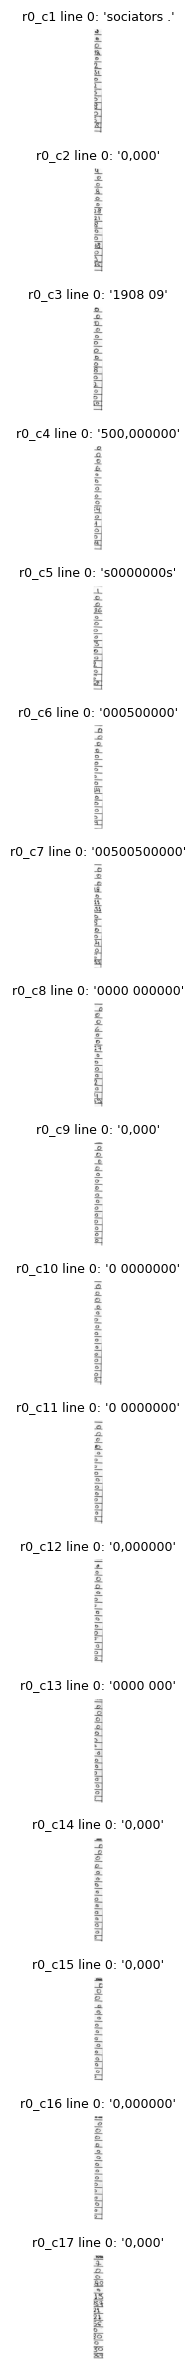

r0_c1: TrOCR='sociators .'   GOT=''
r0_c2: TrOCR='0,000'   GOT=''
r0_c3: TrOCR='1908 09'   GOT=''
r0_c4: TrOCR='500,000000'   GOT=''
r0_c5: TrOCR='s0000000s'   GOT=''
r0_c6: TrOCR='000500000'   GOT=''
r0_c7: TrOCR='00500500000'   GOT=''
r0_c8: TrOCR='0000 000000'   GOT=''
r0_c9: TrOCR='0,000'   GOT=''
r0_c10: TrOCR='0 0000000'   GOT=''
r0_c11: TrOCR='0 0000000'   GOT=''
r0_c12: TrOCR='0,000000'   GOT=''
r0_c13: TrOCR='0000 000'   GOT=''
r0_c14: TrOCR='0,000'   GOT=''
r0_c15: TrOCR='0,000'   GOT=''
r0_c16: TrOCR='0,000000'   GOT=''
r0_c17: TrOCR='0,000'   GOT=''


In [ ]:
preview_image = Image.open(image_files[0]).convert("RGB")
preview_texts, preview_lines, preview_mode = trocr_read_image(preview_image)

print(f"{os.path.basename(image_files[0])}: mode={preview_mode}, cells={len(preview_lines)}")

rows = [(name, i, img) for name, imgs in preview_lines.items() for i, img in enumerate(imgs)]

if rows:
    fig, axes = plt.subplots(len(rows), 1, figsize=(8, max(len(rows), 1) * 1.4))
    if len(rows) == 1:
        axes = [axes]

    for ax, (name, i, img) in zip(axes, rows):
        ax.imshow(img, cmap="gray")
        ax.set_title(f"{name} line {i}: {preview_texts[name].splitlines()[i]!r}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No cells with ink found.")

for name, text in preview_texts.items():
    print(f"{name}: TrOCR={text!r}   GOT={results.get(name, '')!r}")

## Run TrOCR on all images

In [ ]:
trocr_results = {}

for img_path in image_files:
    print(f"Processing image: {os.path.basename(img_path)}")
    try:
        image = Image.open(img_path).convert("RGB")
        texts, cell_lines, mode = trocr_read_image(image)
        trocr_results[img_path] = texts

        n_lines = sum(len(v) for v in cell_lines.values())
        print(f"-> {len(texts)} cells, {n_lines} text lines ({mode})")
    except Exception as e:
        print(f"Error processing {os.path.basename(img_path)}: {e}")

## Compare GOT vs TrOCR and save

Joins both models' outputs on `image_name` + `field_id`. `same` marks cells where both
models agree (ignoring case and spaces). The disagreements are the cells worth checking
by eye, and a good starting set for building a ground-truth file to measure accuracy.

In [ ]:
trocr_df = pd.DataFrame(
    [
        {"image_name": os.path.basename(p), "field_id": field, "trocr_text": text}
        for p, fields in trocr_results.items()
        for field, text in fields.items()
    ],
    columns=["image_name", "field_id", "trocr_text"]
)

comparison_df = final_df.rename(columns={"ocr_text": "got_text"}).merge(
    trocr_df,
    on=["image_name", "field_id"],
    how="outer"
)

def normalize(text):
    return "".join(str(text).lower().split()) if pd.notna(text) else ""

comparison_df["same"] = comparison_df["got_text"].map(normalize) == comparison_df["trocr_text"].map(normalize)

print(f"TrOCR cells: {len(trocr_df)}, GOT cells: {len(final_df)}")
print(f"Models agree on {comparison_df['same'].sum()} of {len(comparison_df)} cells")

trocr_csv_path = os.path.join(OUTPUT_DIR, "trocr_results.csv")
comparison_csv_path = os.path.join(OUTPUT_DIR, "ocr_comparison.csv")

trocr_df.to_csv(trocr_csv_path, index=False, encoding="utf-8")
comparison_df.to_csv(comparison_csv_path, index=False, encoding="utf-8")

print("Saved TrOCR CSV:", trocr_csv_path)
print("Saved comparison CSV:", comparison_csv_path)

In [ ]:
# Cells where the two models disagree
comparison_df[~comparison_df["same"]]